# Entrenamiento de Red CelabA - 40 Atributos Faciales

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    Activation, Dropout,
    BatchNormalization
)
from keras.regularizers import l2
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1790106969.572341   64107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790106969.994289   64107 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790106971.897590   64107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            #Evita que TF reserve toda la VRAM al inicio
        print(f'GPU configurada: {len(gpus)} dispositivo(s)')
    except RuntimeError as e:
        print(e)
else:
    print('No se detectó GPU - usando CPU')

GPU configurada: 1 dispositivo(s)


## Cargamos la base de datos CelebA desde TensorFlow Datasets

In [3]:
dataset_celab, info = tfds.load('celeb_a', with_info=True,
                                 as_supervised=False)
train_dataset_celab = dataset_celab['train']
validation_dataset_celab = dataset_celab['validation']
test_dataset_celab = dataset_celab['test']
print(info)

I0000 00:00:1790106977.679956   64107 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6236 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


tfds.core.DatasetInfo(
    name='celeb_a',
    full_name='celeb_a/2.1.0',
    description="""
    CelebFaces Attributes Dataset (CelebA) is a large-scale face attributes dataset
    with more than 200K celebrity images, each with 40 attribute annotations. The
    images in this dataset cover large pose variations and background clutter.
    CelebA has large diversities, large quantities, and rich annotations,
    including - 10,177 number of identities, - 202,599 number of face images, and -
    5 landmark locations, 40 binary attributes annotations per image.
    
    The dataset can be employed as the training and test sets for the following
    computer vision tasks: face attribute recognition, face detection, and landmark
    (or facial part) localization.
    
    Note: CelebA dataset may contain potential bias. The fairness indicators
    [example](https://www.tensorflow.org/responsible_ai/fairness_indicators/tutorials/Fairness_Indicators_TFCO_CelebA_Case_Study)
    goes into det

# Veamos que tan desbalanceado está nuestro modelo

In [5]:
attribute_names = list(info.features['attributes'].keys())

# Diccionario para sumar cuántas veces aparece cada etiqueta
counts = {name: 0 for name in attribute_names}
total_images = 10000

# Tomamos 10,000 imágenes del set de entrenamiento para analizar
subset = train_dataset_celab.take(total_images)

print("Analizando distribución...")
for element in subset:
    attributes = element['attributes']
    for name in attribute_names:
        # attributes[name] es un booleano (True/False)
        if attributes[name].numpy():
            counts[name] += 1

# Calculamos la distancia al 50% para encontrar las más balanceadas
distances_to_50 = {}
percentages = {}

for name in attribute_names:
    pct = counts[name] / total_images
    percentages[name] = pct
    # mientras más bajo, más cerca del 50/50
    distances_to_50[name] = abs(pct - 0.5)

# Ordenamos las características de menor a mayor distancia
best_balanced = sorted(distances_to_50.items(), key=lambda x: x[1])

print("\n Las 10 categorías más cercanas al 50%")
for name, dist in best_balanced[:10]:
    print(f"{name}: {percentages[name]*100:.2f}%")

Analizando distribución...

 Las 10 categorías más cercanas al 50%
Attractive: 51.38%
Smiling: 48.10%
Mouth_Slightly_Open: 48.07%
Wearing_Lipstick: 46.81%
High_Cheekbones: 45.01%
Male: 41.90%
Heavy_Makeup: 38.53%
Wavy_Hair: 32.26%
Oval_Face: 28.49%
Pointy_Nose: 27.94%


Podemos ver que no todas las carácterísticas están presentes en el modelo, incluso los top 10 no están todos presentes, así que solamente tomaremos los que estén más balanceados para que la red no tenga sesgo.

La característica attractive es subjetiva por lo tanto la descartamos, la categoría Wearing_lepstick no creo que se pueda detectar facilmente en blanco y negro así que la descartamos, el atributo male se me hace más enriquecedor para la red.

In [6]:
atributos_seleccionados = ['Mouth_Slightly_Open', 'Smiling', 'High_Cheekbones', 'Male']
def filter_attributes(element):
    image = element['image']
    image = tf.image.resize(image, (64, 64))
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32) / 255.0
    
    # Extraemos solo las 4 etiquetas elegidas
    labels = [element['attributes'][attr] for attr in atributos_seleccionados]
    labels = tf.cast(labels, tf.float32)
    
    return image, labels

In [7]:
train_ds = train_dataset_celab.map(filter_attributes, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = validation_dataset_celab.map(filter_attributes, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_dataset_celab.map(filter_attributes, num_parallel_calls=tf.data.AUTOTUNE)

BATCH_SIZE = 64
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Visualizamos algunas imágenes del dataset

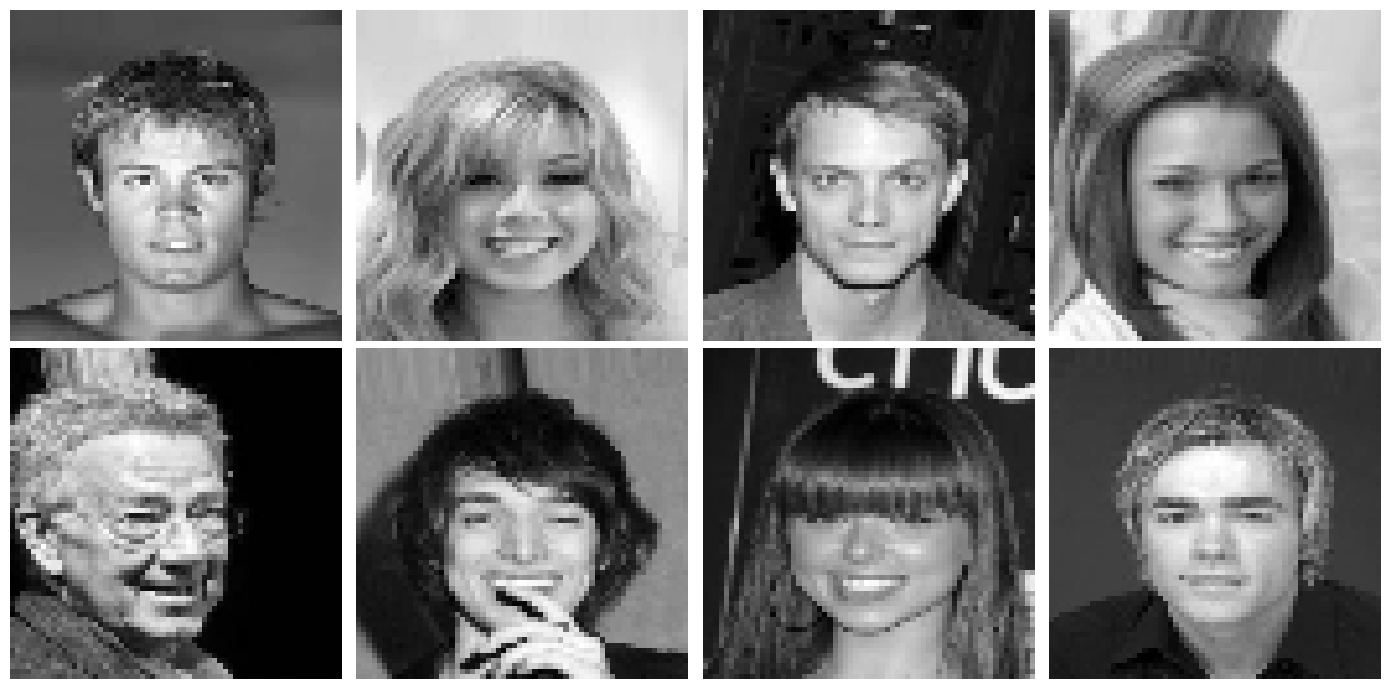

In [7]:
for images, labels in train_ds.take(1):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i].numpy().squeeze(), cmap='gray')
            ax.axis('off')
    plt.tight_layout()
    plt.show()
    break

## Modelo convolucional a entrenar

In [8]:
kernel_reg = l2(1e-04)
inputs = keras.Input(shape=(64, 64, 1))

x = Conv2D(16, (3, 3), activation='relu')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(32, (3, 3), activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Dropout(0.5)(x)

x = Flatten()(x)
x = Dense(256, activation='relu', kernel_regularizer=kernel_reg)(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=kernel_reg)(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,236 (2.47 MB)

 Trainable params: 647,012 (2.47 MB)

 Non-trainable params: 224 (896.00 B)

In [9]:
filepath = "best_model_celab_40.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_loss',
                    verbose=1, save_best_only=True, mode='min')
earlystop = EarlyStopping(monitor='val_loss',
                          mode='min',
                          restore_best_weights=True,
                          patience=15, verbose=1)
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.0001),
              metrics=['binary_accuracy'])

In [10]:
history = model.fit(train_ds,
                   epochs=70,
                   validation_data=val_ds,
                   callbacks=[checkpoint, earlystop],
                   verbose=1
                   )

Epoch 1/70


I0000 00:00:1790052226.145630  244172 service.cc:153] XLA service 0x7fd144ff1be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790052226.145656  244172 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790052226.194000  244172 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790052226.509067  244172 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790052226.583385  244172 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5205442__.59
I0000 00:00:1790052229.496396  244172 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints se

  25/2544 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - binary_accuracy: 0.5031 - loss: 1.7869

I0000 00:00:1790052234.741725  244172 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2528/2544 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6052 - loss: 0.8324

I0000 00:00:1790052249.933764  244169 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5205442__.59


2544/2544 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.6057 - loss: 0.8313
Epoch 1: val_loss improved from None to 0.45895, saving model to best_model_celab_40.keras
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - binary_accuracy: 0.6836 - loss: 0.6695 - val_binary_accuracy: 0.8479 - val_loss: 0.4590
Epoch 2/70
2537/2544 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.8072 - loss: 0.4884
Epoch 2: val_loss improved from 0.45895 to 0.37179, saving model to best_model_celab_40.keras
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - binary_accuracy: 0.8182 - loss: 0.4664 - val_binary_accuracy: 0.8722 - val_loss: 0.3718
Epoch 3/70
2538/2544 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.8396 - loss: 0.4180
Epoch 3: val_loss improved from 0.37179 to 0.32742, saving model to best_model_celab_40.keras
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - binary_accuracy: 0.8456 - loss: 0.4037 - val_binary_accuracy: 0.8846 - val_loss: 0.3274
Epoch 4/70
2543/2544 ━━━━━━━━━━━━━━━━━━━━ 0s

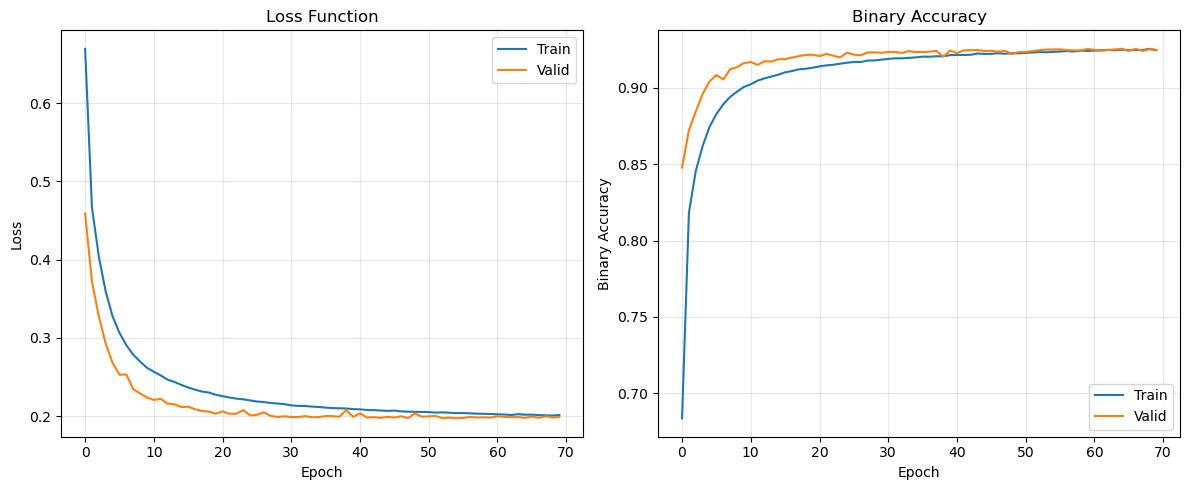

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(history.history['loss'], label='Train')
ax[0].plot(history.history['val_loss'], label='Valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss Function')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(history.history['binary_accuracy'], label='Train')
ax[1].plot(history.history['val_binary_accuracy'], label='Valid')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Binary Accuracy')
ax[1].set_title('Binary Accuracy')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Evaluar en test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Binary Accuracy: {test_acc:.4f}')

312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - binary_accuracy: 0.9202 - loss: 0.2071
Test Loss: 0.2071
Test Binary Accuracy: 0.9202


Podemos ver que el modelo tiene un gran éxito, por lo que podemos decir que extrae carácterísticas suficientes del rostro.